In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def exact(x, t):
    return np.sin(2 * np.pi * (x - t))

In [3]:
v = 1.15
times = [0, 0.25, 0.5, 0.75, 1.0]

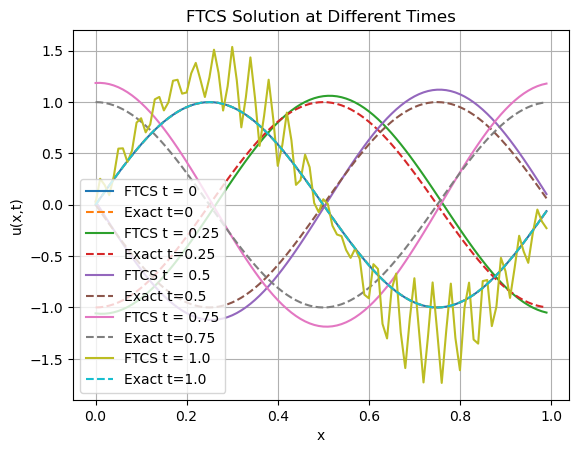

In [4]:
for t in times:
    filename = f"ftcs_{t}_v_{v:.2f}.dat"
    
    try:
        data = np.loadtxt(filename)
        x = data[:,0]
        u = data[:,1]
        plt.plot(x, u, label=f"FTCS t = {t}")
        plt.plot(x, exact(x, t), '--', label=f"Exact t={t}")
    except:
        print(f"File not found: {filename}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("FTCS Solution at Different Times")
plt.legend()
plt.grid()


data = np.loadtxt(f"ftcs_absmax_v_{v:.2f}.dat")
time = data[:,0]
max_val = data[:,1]

if np.max(max_val) > 10:
    print("Solution is diverging → plotting first 50 timesteps")

    plt.figure()
    files = sorted(glob.glob(f"ftcs_*_v_{v:.2f}.dat"))

    count = 0
    for file in files:
        if "absmax" in file:
            continue
        
        data = np.loadtxt(file)
        x = data[:,0]
        u = data[:,1]

        plt.plot(x, u, label=file.split("_")[1])

        count += 1
        if count >= 50:
            break

    plt.ylim([-5, 5])
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.title("First 50 timesteps (clipped view)")
    plt.legend()
    plt.grid()
    plt.show()

Total timesteps available = 87
Using first 87 timesteps


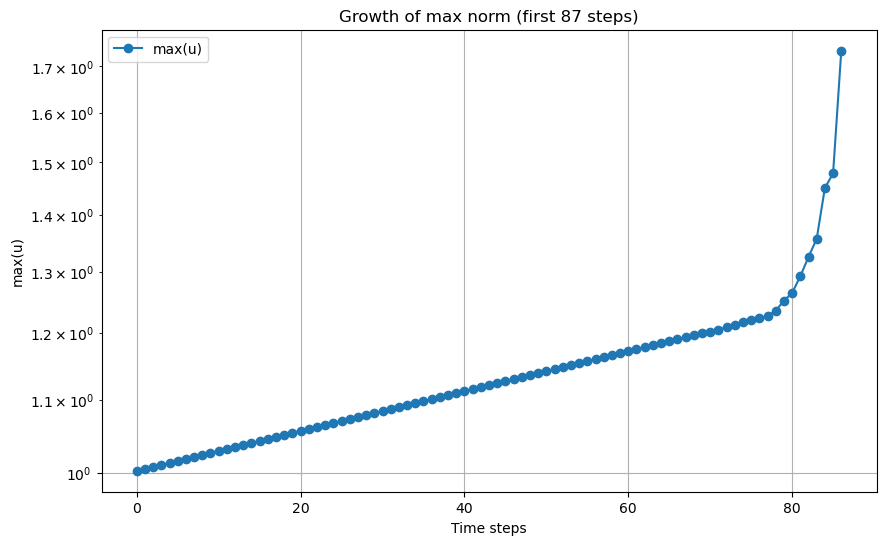

Estimated growth rate = 0.00327


In [5]:
data = np.loadtxt(f"ftcs_absmax_v_{v:.2f}.dat")

time = data[:,0]
max_val = data[:,1]

NT = len(time)

N_use = min(NT, 200)

print(f"Total timesteps available = {NT}")
print(f"Using first {N_use} timesteps")

time_use = time[:N_use]
max_use = max_val[:N_use]

plt.figure(figsize=(10,6))
plt.plot(range(N_use), max_use, marker='o', label="max(u)")

plt.yscale('log')

plt.xlabel("Time steps")
plt.ylabel("max(u)")
plt.title(f"Growth of max value (first {N_use} steps)")
plt.grid()
plt.legend()

plt.show()

mask = max_use > 1e-12

n = np.arange(N_use)[mask]
log_u = np.log(max_use[mask])

coeffs = np.polyfit(n, log_u, 1)
growth_rate = coeffs[0]

print(f"Estimated growth rate = {growth_rate:.5f}")